In [1]:
# Step 1: Import required libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create directories if not exist
os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [2]:
# Step 2: Create SQLite database and insert data
conn = sqlite3.connect("data/sales_data.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Sample sales data
data = [
    ("Laptop", 5, 800.0),
    ("Laptop", 2, 850.0),
    ("Phone", 10, 500.0),
    ("Phone", 4, 520.0),
    ("Tablet", 7, 300.0),
    ("Tablet", 3, 310.0),
    ("Headphones", 15, 50.0),
    ("Headphones", 20, 45.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", data)
conn.commit()

print("✅ Database created and sample data inserted!")

✅ Database created and sample data inserted!


In [3]:
# Step 3: Query sales summary
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)
df


,product,total_qty,revenue
0,Headphones,35,1650.0
1,Laptop,7,5700.0
2,Phone,14,7080.0
3,Tablet,10,3030.0


In [4]:
# Step 4: Save summary to file
with open("results/summary_output.txt", "w") as f:
    f.write(df.to_string(index=False))

print("✅ Summary saved to results/summary_output.txt")

✅ Summary saved to results/summary_output.txt


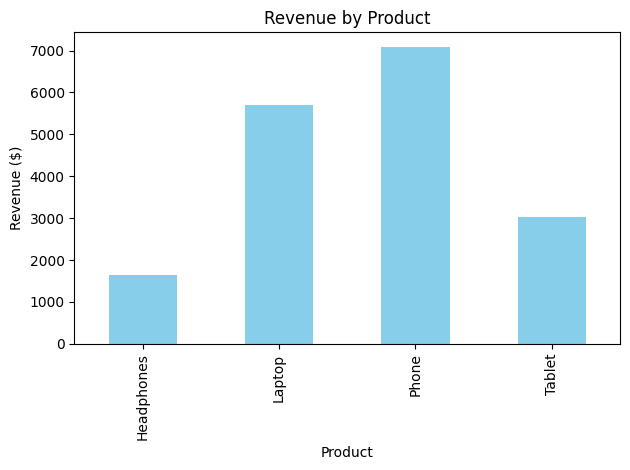

✅ Chart saved to results/sales_chart.png


In [5]:
# Step 5: Plot revenue by product
df.plot(kind="bar", x="product", y="revenue", legend=False, color="skyblue")
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("results/sales_chart.png")
plt.show()

print("✅ Chart saved to results/sales_chart.png")